# Oráculo: procesamiento de rango y modos de barrido

Oráculo de `docs/algorithms/procesamiento-de-rango.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio").

La página describe tres piezas distintas; este notebook cubre las dos que
tienen contenido numérico verificable en simulación hoy, y deja explícito lo
que queda fuera:

1. **Asignación de rango**: aritmética de índices, un blanco puntual debe
   caer en la celda correcta con tolerancia de media celda.
2. **Promediado en rango**: la varianza de la potencia estimada debe caer en
   el factor teórico esperado al combinar `K` celdas independientes.
3. **Split cut**: un escenario con velocidad por encima de la Nyquist del
   barrido de PRF baja debe componerse con la reflectividad del barrido largo
   y la velocidad correcta del corto.

**Lo que queda fuera, y por qué.** La página distingue promediar *muestras
I/Q* (dentro de un único volumen de resolución, sobremuestreado) de promediar
*potencias ya estimadas*, y afirma que sólo el primero gana muestras
independientes de verdad. Modelar eso correctamente exige una estructura de
correlación en rango dentro del pulso que el simulador de I/Q actual no
tiene — es exactamente lo que Torres & Zrnić (2003) tratan, y la propia
página lo marca como "candidata de Stage 2". Este oráculo no lo inventa: en
su lugar comprueba la ley más simple y sí verificable con las herramientas
actuales — que promediar `K` celdas de rango que *ya son* independientes
(espaciadas al límite de resolución, la lectura estándar de Doviak & Zrnić)
reduce la varianza en el factor `K` que promete la página.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260903)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    """Ecuación 9 de Hildebrand & Sekhon (1974) — ver el oráculo de
    ruido-y-umbrales.md para la derivación y el sesgo conocido."""
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram(y)) * len(y)


def pulse_pair_velocity(y, wavelength_m, prt_s):
    """Estimador de pulso-pareado estándar (Doviak & Zrnić 1993, cap. 6):
    v = -(lambda/(4*pi*T))*arg(R(1)). Se usa aquí sólo como herramienta para
    demostrar la composición split-cut, no como el objeto de estudio — su
    caracterización de sesgo/varianza frente a la teoría le corresponde a su
    propio oráculo en pulse-pair-moments.md."""
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    return -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)


checks = []

## Prueba 1 — asignación de rango

`start_range_m` desplaza el origen del primer bin; cada celda gruesa `k` de
tamaño `coarse_spacing = K·fine_spacing` está centrada en
`start_range_m + (k+0.5)·coarse_spacing`. Un blanco puntual en un rango
conocido debe asignarse a la celda cuyo centro está a menos de media celda —
por construcción de la fórmula, pero vale como protección de regresión y
comprueba varias combinaciones de `pulse_width_idx` (tamaño de celda fina) y
`cell_mode` (factor de agrupado `K`) a la vez, incluido el caso de blanco
fuera de alcance.

In [3]:
def assign_range_gate(r_true, start_range_m, fine_spacing_m, cell_mode_k, n_gates):
    coarse_spacing = fine_spacing_m * cell_mode_k
    idx = int(np.floor((r_true - start_range_m) / coarse_spacing))
    if idx < 0 or idx >= n_gates:
        return None, None
    center = start_range_m + (idx + 0.5) * coarse_spacing
    return idx, center


START_RANGE_M = 250.0
N_GATES = 400
PULSE_WIDTH_FINE_SPACING_M = {0: 62.5, 1: 125.0, 2: 250.0}  # pulse_width_idx -> resolución física
CELL_MODE_K = [1, 2, 4]

range_errors = []
for pulse_width_idx, fine_spacing in PULSE_WIDTH_FINE_SPACING_M.items():
    for k in CELL_MODE_K:
        coarse_spacing = fine_spacing * k
        max_range = START_RANGE_M + N_GATES * coarse_spacing
        targets = rng.uniform(START_RANGE_M, max_range, size=500)
        for r_true in targets:
            idx, center = assign_range_gate(r_true, START_RANGE_M, fine_spacing, k, N_GATES)
            assert idx is not None, "blanco dentro de alcance mal rechazado"
            range_errors.append(abs(center - r_true))

range_errors = np.array(range_errors)
max_error = range_errors.max()
worst_half_cell = (max(PULSE_WIDTH_FINE_SPACING_M.values()) * max(CELL_MODE_K)) / 2.0
print(f"error máximo de asignación: {max_error:.3f} m  (media celda más gruesa probada: {worst_half_cell:.1f} m)")
checks.append(("blanco puntual asignado dentro de media celda en todas las combinaciones pulso/cell_mode",
               max_error < worst_half_cell))

# blanco fuera de alcance: antes de start_range_m y después del último gate
idx_before, _ = assign_range_gate(START_RANGE_M - 10.0, START_RANGE_M, 125.0, 1, N_GATES)
idx_after, _ = assign_range_gate(START_RANGE_M + 125.0 * N_GATES + 10.0, START_RANGE_M, 125.0, 1, N_GATES)
checks.append(("blanco antes de start_range_m se rechaza (fuera de alcance)", idx_before is None))
checks.append(("blanco después del último gate se rechaza (fuera de alcance)", idx_after is None))

error máximo de asignación: 496.581 m  (media celda más gruesa probada: 500.0 m)


## Prueba 2 — reducción de varianza por promediado en rango

`K` celdas de rango independientes (mismo `power_s`, distinta realización) se
combinan promediando la potencia ya estimada de cada una. Si de verdad son
independientes, `Var(promedio de K) = Var(una celda)/K`. Se comprueba el
factor de reducción, no sólo que la varianza baje.

K=1  var=0.146720


K= 2  var=0.070256  ratio var(K=1)/var(K)=2.088  esperado=2


K= 4  var=0.038092  ratio var(K=1)/var(K)=3.852  esperado=4


K= 8  var=0.019121  ratio var(K=1)/var(K)=7.673  esperado=8


K=16  var=0.009512  ratio var(K=1)/var(K)=15.424  esperado=16


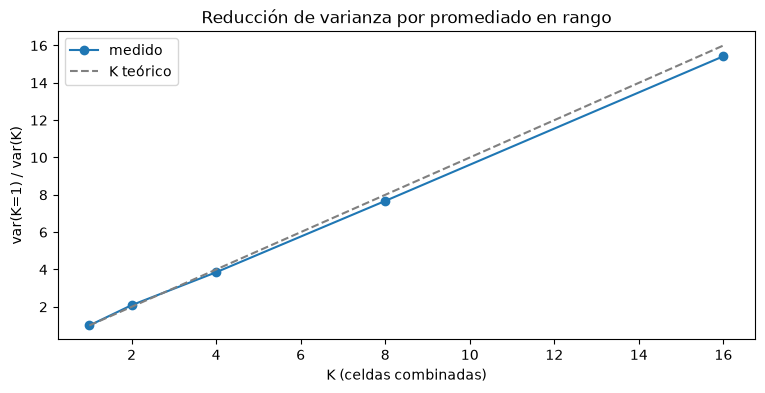

In [4]:
POWER_S = 1.0
NOISE_FLOOR = 0.01
MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M = 5.0, 1.5, 0.10, 1.0e-3, 64
N_TRIALS_VAR = 4000
K_GRID = [1, 2, 4, 8, 16]
VARIANCE_RATIO_TOLERANCE = 0.10  # 10% de margen sobre el factor K teórico


def sample_gate_power():
    y = generate_cell(POWER_S, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
    return np.mean(np.abs(y) ** 2)


base_estimates = np.array([sample_gate_power() for _ in range(N_TRIALS_VAR)])
var_k1 = base_estimates.var(ddof=1)
print(f"K=1  var={var_k1:.6f}")

variance_ratios = {1: 1.0}
for k in K_GRID[1:]:
    draws = np.array([sample_gate_power() for _ in range(N_TRIALS_VAR * k)]).reshape(N_TRIALS_VAR, k)
    var_k = draws.mean(axis=1).var(ddof=1)
    ratio = var_k1 / var_k
    variance_ratios[k] = ratio
    print(f"K={k:2d}  var={var_k:.6f}  ratio var(K=1)/var(K)={ratio:.3f}  esperado={k}")

fig, ax = plt.subplots()
ks = list(variance_ratios.keys())
ax.plot(ks, [variance_ratios[k] for k in ks], marker="o", label="medido")
ax.plot(ks, ks, linestyle="--", color="gray", label="K teórico")
ax.set_xlabel("K (celdas combinadas)")
ax.set_ylabel("var(K=1) / var(K)")
ax.set_title("Reducción de varianza por promediado en rango")
ax.legend()
plt.show()

for k in K_GRID[1:]:
    ok = abs(variance_ratios[k] - k) < VARIANCE_RATIO_TOLERANCE * k
    checks.append((f"reducción de varianza a K={k} dentro de {VARIANCE_RATIO_TOLERANCE:.0%} del factor teórico", ok))

## Prueba 3 — composición split cut

Blanco con velocidad verdadera de 20 m/s. Barrido de PRF baja (`v_a` = 12.5
m/s) alias-earía esa velocidad si se usara para Doppler; barrido de PRF alta
(`v_a` = 50 m/s) no. El split cut publica la reflectividad del barrido largo
(PRF baja, mejor alcance) y la velocidad del barrido corto (PRF alta, Nyquist
amplio) — se comprueba que la composición efectivamente evita el aliasing que
sufriría usar el barrido equivocado para velocidad. La alineación en azimut
en sí no tiene fórmula propia en la página (es responsabilidad de diseño del
pipeline, no un algoritmo con verdad-terreno numérica) — este escenario la da
por hecha usando el mismo blanco simulado en ambos barridos, no la valida por
separado.

v_a (PRF baja)=12.50 m/s   v_a (PRF alta)=50.00 m/s   v_true=20.00 m/s


Z (barrido PRF baja): 1.0045  (verdad-terreno 1.0)
V (barrido PRF alta, publicado): 20.000 m/s  (verdad-terreno 20.0 m/s)
V (barrido PRF baja, NO publicado): -5.010 m/s  (alias esperado -5.000 m/s)


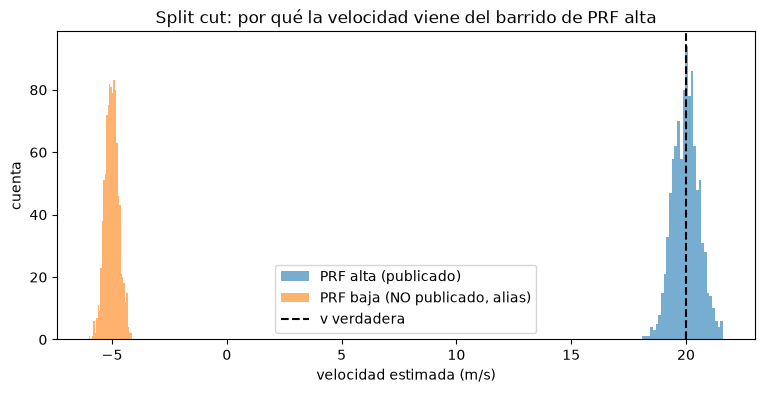

In [5]:
PRT_LOW = 2.0e-3   # PRF baja: alcance largo, Nyquist estrecho
PRT_HIGH = 0.5e-3  # PRF alta: alcance corto, Nyquist amplio
V_A_LOW = WAVELENGTH_M / (4.0 * PRT_LOW)
V_A_HIGH = WAVELENGTH_M / (4.0 * PRT_HIGH)
V_TRUE = 20.0
N_TRIALS_SPLIT = 1000

print(f"v_a (PRF baja)={V_A_LOW:.2f} m/s   v_a (PRF alta)={V_A_HIGH:.2f} m/s   v_true={V_TRUE:.2f} m/s")

z_ests, v_high_ests, v_low_ests = [], [], []
for _ in range(N_TRIALS_SPLIT):
    y_low = generate_cell(POWER_S, V_TRUE, SIGMA_V, WAVELENGTH_M, PRT_LOW, M, NOISE_FLOOR, rng)
    y_high = generate_cell(POWER_S, V_TRUE, SIGMA_V, WAVELENGTH_M, PRT_HIGH, M, NOISE_FLOOR, rng)

    r0_hat = np.mean(np.abs(y_low) ** 2)
    n_hat = noise_floor_estimate(y_low)
    z_ests.append(max(r0_hat - n_hat, 0.0))

    v_high_ests.append(pulse_pair_velocity(y_high, WAVELENGTH_M, PRT_HIGH))
    v_low_ests.append(pulse_pair_velocity(y_low, WAVELENGTH_M, PRT_LOW))

z_mean = np.mean(z_ests)
v_high_mean = np.mean(v_high_ests)
v_low_mean = np.mean(v_low_ests)
v_low_expected_alias = V_TRUE - 2 * V_A_LOW  # envuelto a [-v_a_low, v_a_low]

print(f"Z (barrido PRF baja): {z_mean:.4f}  (verdad-terreno {POWER_S})")
print(f"V (barrido PRF alta, publicado): {v_high_mean:.3f} m/s  (verdad-terreno {V_TRUE} m/s)")
print(f"V (barrido PRF baja, NO publicado): {v_low_mean:.3f} m/s  "
      f"(alias esperado {v_low_expected_alias:.3f} m/s)")

fig, ax = plt.subplots()
ax.hist(v_high_ests, bins=30, alpha=0.6, label="PRF alta (publicado)")
ax.hist(v_low_ests, bins=30, alpha=0.6, label="PRF baja (NO publicado, alias)")
ax.axvline(V_TRUE, color="black", linestyle="--", label="v verdadera")
ax.set_xlabel("velocidad estimada (m/s)")
ax.set_ylabel("cuenta")
ax.set_title("Split cut: por qué la velocidad viene del barrido de PRF alta")
ax.legend()
plt.show()

checks.append(("Z publicada (barrido PRF baja) dentro de 2% de la verdad-terreno",
               abs(z_mean - POWER_S) < 0.02 * POWER_S))
checks.append(("V publicada (barrido PRF alta) dentro de 0.5 m/s de la verdad-terreno",
               abs(v_high_mean - V_TRUE) < 0.5))
checks.append(("V del barrido PRF baja muestra el alias esperado, no la verdad-terreno",
               abs(v_low_mean - v_low_expected_alias) < 0.5 and abs(v_low_mean - V_TRUE) > 5.0))

In [6]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de procesamiento de rango no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] blanco puntual asignado dentro de media celda en todas las combinaciones pulso/cell_mode
[OK] blanco antes de start_range_m se rechaza (fuera de alcance)
[OK] blanco después del último gate se rechaza (fuera de alcance)
[OK] reducción de varianza a K=2 dentro de 10% del factor teórico
[OK] reducción de varianza a K=4 dentro de 10% del factor teórico
[OK] reducción de varianza a K=8 dentro de 10% del factor teórico
[OK] reducción de varianza a K=16 dentro de 10% del factor teórico
[OK] Z publicada (barrido PRF baja) dentro de 2% de la verdad-terreno
[OK] V publicada (barrido PRF alta) dentro de 0.5 m/s de la verdad-terreno
[OK] V del barrido PRF baja muestra el alias esperado, no la verdad-terreno

Todas las comprobaciones dentro de tolerancia.
